In [1]:
import numpy as np
def giai_thua(n):
    if n==0 or n==1:
        return 1
    return n*giai_thua(n-1)
for val in [3,4]:
    print(f"giai thừa của {val} là: {giai_thua(val)}")

giai thừa của 3 là: 6
giai thừa của 4 là: 24


In [2]:
def fibonacci(n):
    if n<=1:
        return n
    return fibonacci(n-1)+fibonacci(n-2)
for i in [4,5,6]:
    print(f"F({i})={fibonacci(i)}")

F(4)=3
F(5)=5
F(6)=8


In [4]:
from sympy import Symbol, solve, Eq
def day_so3(n):
    if n==1:
        return 0.5
    an_prev=day_so3(n-1)
    return an_prev**an_prev
vals3=[day_so3(i) for i in range(1,11)]
for i,v in enumerate(vals3,1):
    print(f"a({i})={v:.6f}")
L=Symbol('L')
pt3=Eq(L,L**L)
print(f"Giới hạn tiềm năng(điểm bất động):{solve(pt3,L)}")

a(1)=0.500000
a(2)=0.707107
a(3)=0.782654
a(4)=0.825471
a(5)=0.853571
a(6)=0.873591
a(7)=0.888643
a(8)=0.900403
a(9)=0.909861
a(10)=0.917641
Giới hạn tiềm năng(điểm bất động):[-1, 1]


In [5]:
def dayso4(n):
    if n==1:
        return 4.0
    anprev=dayso4(n-1)
    return 5/(6-anprev)
for i in [5,6,7,10]:
    print(f"a({i})={dayso4(i):.6f}")
pt4=Eq(L,5/(6-L))
print(f"Giới hạn của dãy(Điểm bất động):{solve(pt4,L)}")

a(5)=1.019108
a(6)=1.003836
a(7)=1.000768
a(10)=1.000006
Giới hạn của dãy(Điểm bất động):[1, 5]


x(1)=1.000000
x(2)=2.000000
x(3)=1.500000
x(4)=1.666667
x(5)=1.600000
x(6)=1.625000
x(7)=1.615385
x(8)=1.619048
x(9)=1.617647
x(10)=1.618182


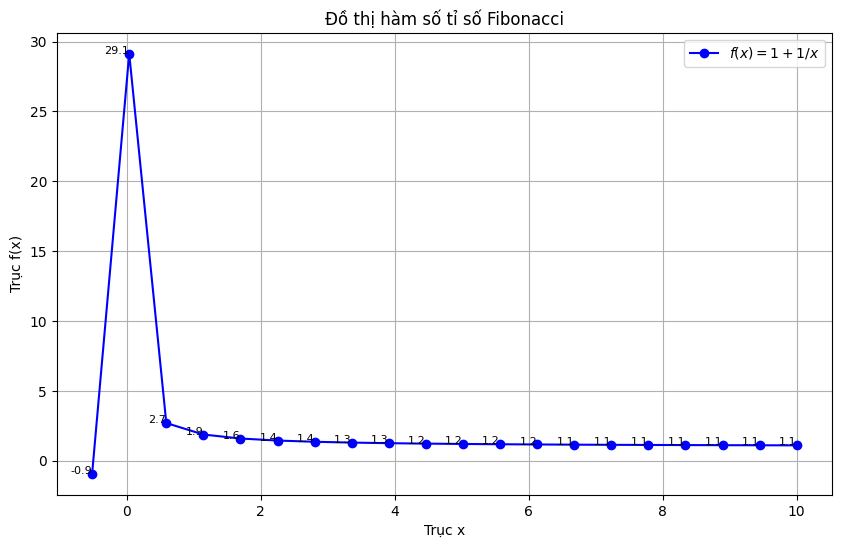

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import sqrt
def xnfib(n):
    return fibonacci(n+1)/fibonacci(n)
xvals=[xnfib(i) for i in range(1,11)]
for i, x in enumerate(xvals,1):
    print(f"x({i})={x:.6f}")
neg_root=float((1-sqrt(5))/2)
xplot=np.linspace(neg_root+0.1,10,20)
yplot=1+1/xplot
plt.figure(figsize=(10,6))
plt.plot(xplot,yplot,marker='o',linestyle='-',color='b',label='$f(x)=1+1/x$')
for i,(xi,yi) in enumerate(zip(xplot,yplot)):
    plt.text(xi,yi,f'{yi:.1f}',fontsize=8,ha='right')
plt.title('Đồ thị hàm số tỉ số Fibonacci')
plt.xlabel('Trục x')
plt.ylabel('Trục f(x)')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from sympy import Symbol, Derivative, log, exp, cos

def gradient_ascent(f, var, x0, eta=0.01, steps=100):
    d_sym = Derivative(f, var)
    df = d_sym.doit()
    
    x_curr = x0
    for i in range(steps):
        grad_val = df.subs(var, x_curr)
        if grad_val == 0:
            print(f"Đạo hàm bằng 0 tại bước {i}. Dừng.")
            return x_curr
        try:
            x_curr = float(x_curr + eta * grad_val)
        except Exception as e:
            print(f"Lỗi: {e}")
            return None
    return x_curr

x = Symbol('x')
t = Symbol('t')

print("--- Thử nghiệm Gradient Ascent ---")

print(f"Cực đại log(x) khởi đầu 0.1: {gradient_ascent(log(x), x, 0.1)}")
print(f"Cực đại e^x khởi đầu 0.1: {gradient_ascent(exp(x), x, 0.1)}")

print(f"Cực đại cos(t) khởi đầu 0.01: {gradient_ascent(cos(t), t, 0.01)}")

f_poly = x**5 - 30*x**3 + 50*x
print(f"Với x0 = -2: {gradient_ascent(f_poly, x, -2.0)}")
print(f"Với x0 = 0.5: {gradient_ascent(f_poly, x, 0.5)}")

--- Thử nghiệm Gradient Ascent ---
Cực đại log(x) khởi đầu 0.1: 1.4284064040284612
Cực đại e^x khởi đầu 0.1: inf
Cực đại cos(t) khởi đầu 0.01: 0.003660350229812417
Với x0 = -2: nan
Với x0 = 0.5: 0.7575290270502124


In [ ]:
from sympy import Symbol, Eq, solve, log, Derivative

W = Symbol('W')
G_W = W * (0.5 - 0.05 * log(W))

print("--- Bài tập Chương 6: Tế bào ung thư ---")

pt_can_bang = Eq(G_W, 0)
sol_can_bang = solve(pt_can_bang, W)
print(f"Khối lượng mg khi cân bằng: {sol_can_bang}")

dG_symbolic = Derivative(G_W, W)
print(f"Phép tính đạo hàm ký hiệu: {dG_symbolic}")

dG_val = dG_symbolic.doit()
print(f"Biểu thức đạo hàm G'(W): {dG_val}")

max_growth_rate = solve(Eq(dG_val, 0), W)
print(f"Khối lượng để tế bào tăng nhanh nhất: {max_growth_rate} mg")

--- Bài tập Chương 6: Tế bào ung thư ---
Khối lượng mg khi cân bằng: [0.0, 22026.4657948067]
Phép tính đạo hàm ký hiệu: Derivative(W*(0.5 - 0.05*log(W)), W)
Biểu thức đạo hàm G'(W): 0.45 - 0.05*log(W)
Khối lượng để tế bào tăng nhanh nhất: [8103.08392757538] mg
